# Best Model Analysis

This notebook analyzes the overall best model, defined as the model trained with a particular seed that achieves the highest accuracy with the lowest n_gaussians.

## Setup

In [29]:
from pathlib import Path
from typing import Any, TypedDict

import matplotlib.pyplot as plt
import numpy as np
import optuna
import scienceplots  # noqa: F401
import torch
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix

from csi_vae.jobs import JobSettings, dataset, fusion, vae
from csi_vae.jobs.job import make_dataloader

plt.style.use(["science", "no-latex", "bright"])
plt.rcParams.update({"figure.dpi": 300})

settings = JobSettings()

LAUNCH_DIR = Path("../out/flat_conv_full")
WEIGHTS_DIR = Path("../weights")
PLOTS_DIR = LAUNCH_DIR / "plots"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ACTIVITIES = [
    "Walk",
    "Run",
    "Jump",
    "Sit",
    "Empty",
    "Stand",
    "Waving",
    "Clap",
    "Lay down",
    "Wipe",
    "Squat",
    "Stretch",
]

PLOTS_DIR.mkdir(exist_ok=True)

In [30]:
full_train_ds, full_val_ds, full_test_ds = dataset.load(
    dataset_path=Path("../") / settings.dataset_path,
    window_size=settings.window_size,
    n_activities=settings.n_activities,
    stride=settings.stride,
)
full_ds = torch.utils.data.ConcatDataset([full_train_ds, full_val_ds, full_test_ds])

In [31]:
class _ModelReport(TypedDict):
    n_gaussians: int
    trial_number: int
    trial_value: float
    seed: int
    best_seed_accuracy: float
    params: dict[str, Any]

## Load Best Models

In [32]:
studies_files = sorted([f.name for f in LAUNCH_DIR.iterdir() if f.is_file() and f.suffix == ".sqlite"])
studies = [
    optuna.load_study(study_name=study.split(".")[0], storage=f"sqlite:///{LAUNCH_DIR / study}").trials_dataframe()
    for study in studies_files
]

In [33]:
best_models_per_study: list[_ModelReport] = []

for i, study in enumerate(studies):
    completed = study[study["state"] == "COMPLETE"].copy()
    study_best: _ModelReport = _ModelReport(
        n_gaussians=i + 1,
        trial_number=0,
        trial_value=0.0,
        seed=0,
        best_seed_accuracy=0.0,
        params={},
    )
    study_best_trial = 0
    study_best_trial_value = 0.0

    for _, trial in completed.iterrows():
        accuracies_per_seed = trial["user_attrs_accuracies"]

        best_seed = max(accuracies_per_seed, key=accuracies_per_seed.get)
        best_accuracy = float(accuracies_per_seed[str(best_seed)])

        if trial["value"] > study_best["trial_value"]:
            study_best = _ModelReport(
                n_gaussians=i + 1,
                trial_number=trial["number"],
                trial_value=trial["value"],
                seed=int(best_seed),
                best_seed_accuracy=best_accuracy,
                params=trial.filter(like="params_").rename(lambda x: x.replace("params_", "")).to_dict(),
            )

    best_models_per_study.append(study_best)

best_model = max(best_models_per_study, key=lambda x: x["best_seed_accuracy"])
print(
    f"Best model: n_gaussians={best_model['n_gaussians']}, "
    f"trial_number={best_model['trial_number']}, "
    f"seed={best_model['seed']}, "
    f"accuracy={best_model['best_seed_accuracy']:.4f}",
)

Best model: n_gaussians=2, trial_number=77, seed=347227206, accuracy=0.9812


## Plot Best Models

In [34]:
def plot_tsne(gaussians: list[vae.SingleAntenna], dataloader: torch.utils.data.DataLoader, seed: int) -> None:
    """Plot t-SNE of the latent space for each antenna's Gaussian encoder.

    Arguments:
        gaussians: List of Gaussian encoders, one per antenna.
        dataloader: DataLoader for the dataset to extract latents from.
        seed: Random seed for t-SNE reproducibility.

    """
    antennas_latents, antennas_labels = [], []

    for antenna_idx, gaussian in enumerate(gaussians):
        antenna_latents, antenna_labels = [], []

        gaussian.eval().to(DEVICE)
        for x, y in dataloader:
            with torch.no_grad():
                x_antenna = x[:, antenna_idx].to(DEVICE, dtype=torch.float32)
                mu, logvar = gaussian.encode(x_antenna)

                antenna_latents.append(torch.cat([mu, logvar], dim=1).cpu().numpy())
                antenna_labels.append(y.numpy())

        antennas_latents.append(np.concatenate(antenna_latents))
        antennas_labels.append(np.concatenate(antenna_labels))

    fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=True)
    axes = axes.ravel()

    last_scatter = None

    for antenna_idx, (latents, labels) in enumerate(zip(antennas_latents, antennas_labels, strict=True)):
        tsne = TSNE(
            n_components=2,
            random_state=seed,
            perplexity=30,
        ).fit_transform(latents)

        ax = axes[antenna_idx]
        last_scatter = ax.scatter(
            tsne[:, 0],
            tsne[:, 1],
            c=labels,
            cmap="tab20",
            alpha=0.6,
            edgecolor="w",
            s=8,
            linewidths=0,
            vmin=0,
            vmax=len(ACTIVITIES) - 1,
        )

        ax.set_title(f"Antenna {antenna_idx + 1}")
        ax.set_xlabel("t-SNE 1")
        ax.set_ylabel("t-SNE 2" if antenna_idx == 0 else "")
        ax.grid(True, linestyle="--", alpha=0.5)

    handles, _ = last_scatter.legend_elements(prop="colors", num=len(ACTIVITIES))  # pyright: ignore[reportOptionalMemberAccess]
    fig.legend(
        handles,
        ACTIVITIES,
        title="Activities",
        loc="upper center",
        bbox_to_anchor=(0.5, 1.08),
        ncol=len(ACTIVITIES),
        frameon=True,
        borderaxespad=0.2,
    )

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "best_tsne_gaussians.pdf", bbox_inches="tight")
    plt.show()

In [35]:
def plot_confusion_matrix(model: fusion.Delayed, dataloader: torch.utils.data.DataLoader) -> None:
    """Plot confusion matrix of the model's predictions on the given dataloader.

    Arguments:
        model: The trained fusion.Delayed model to evaluate.
        dataloader: DataLoader for the dataset to evaluate on.

    """
    y_preds, y_trues = [], []
    for x, y in dataloader:
        with torch.no_grad():
            y_pred = model(x.to(DEVICE, dtype=torch.float32))
            y_preds.append(y_pred.cpu().numpy())
            y_trues.append(y.numpy())

    cm = confusion_matrix(
        np.concatenate(y_trues),
        np.concatenate(y_preds).argmax(axis=1),
    )

    plt.figure(figsize=(8, 6))
    # Normalize by row (True Labels) to see percentages
    matrix_perc = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-12)

    plt.imshow(matrix_perc, cmap="Blues")

    thresh = matrix_perc.max() / 2
    for i in range(len(ACTIVITIES)):
        for j in range(len(ACTIVITIES)):
            # Skip zero counts for better readability
            if cm[i, j] == 0:
                continue

            color = "white" if matrix_perc[i, j] > thresh else "black"
            text = f"{matrix_perc[i, j] * 100:.1f}".rstrip("0").rstrip(".")
            plt.text(j, i, text, ha="center", va="center", color=color)

    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.xticks(rotation=45, ha="right", ticks=np.arange(len(ACTIVITIES)), labels=ACTIVITIES)
    plt.yticks(rotation=0, ticks=np.arange(len(ACTIVITIES)), labels=ACTIVITIES)

    ax = plt.gca()
    ax.set_xticks(np.arange(-0.5, len(ACTIVITIES)), minor=True)
    ax.set_yticks(np.arange(-0.5, len(ACTIVITIES)), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "best_confusion_matrix_gaussians.pdf", bbox_inches="tight")
    plt.show()

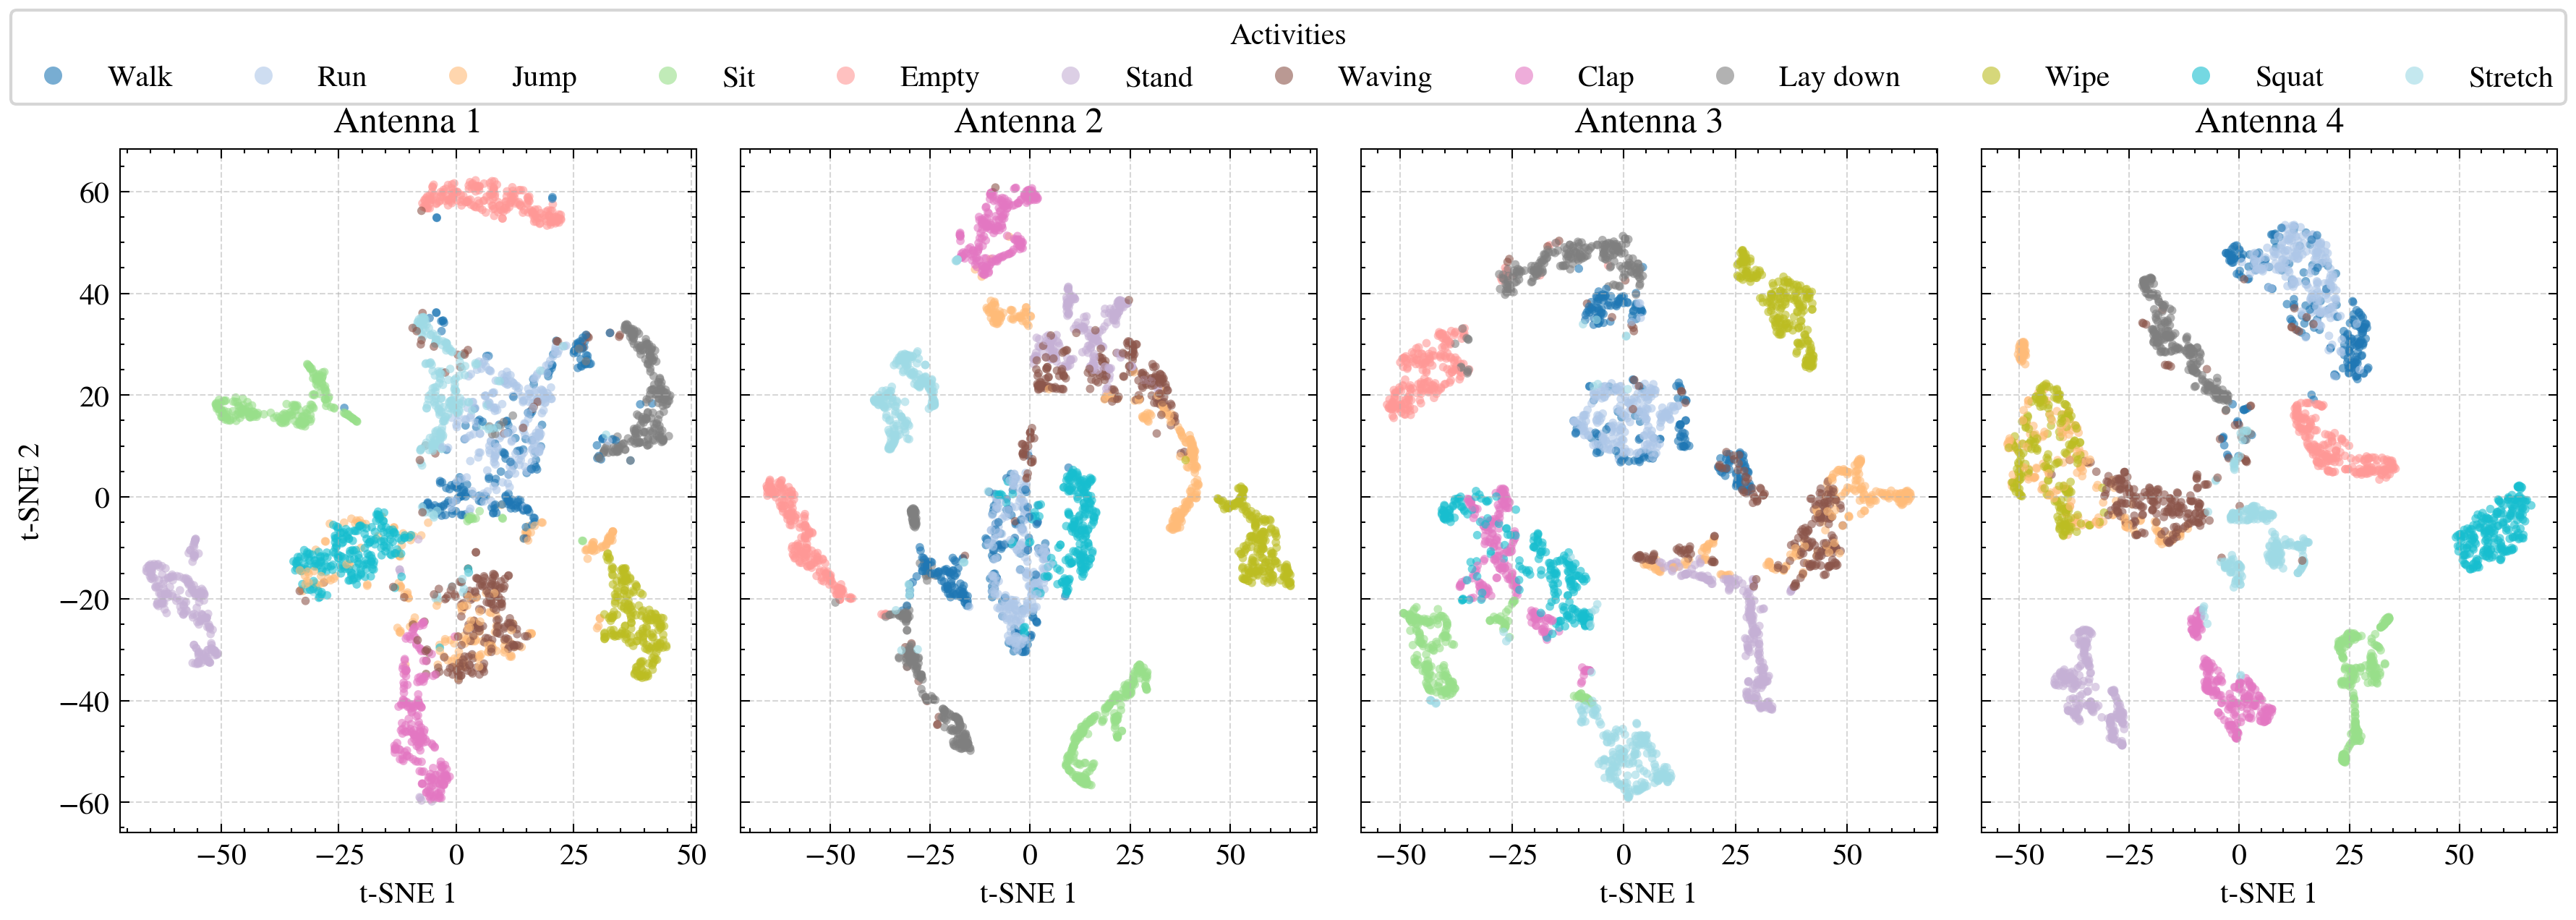

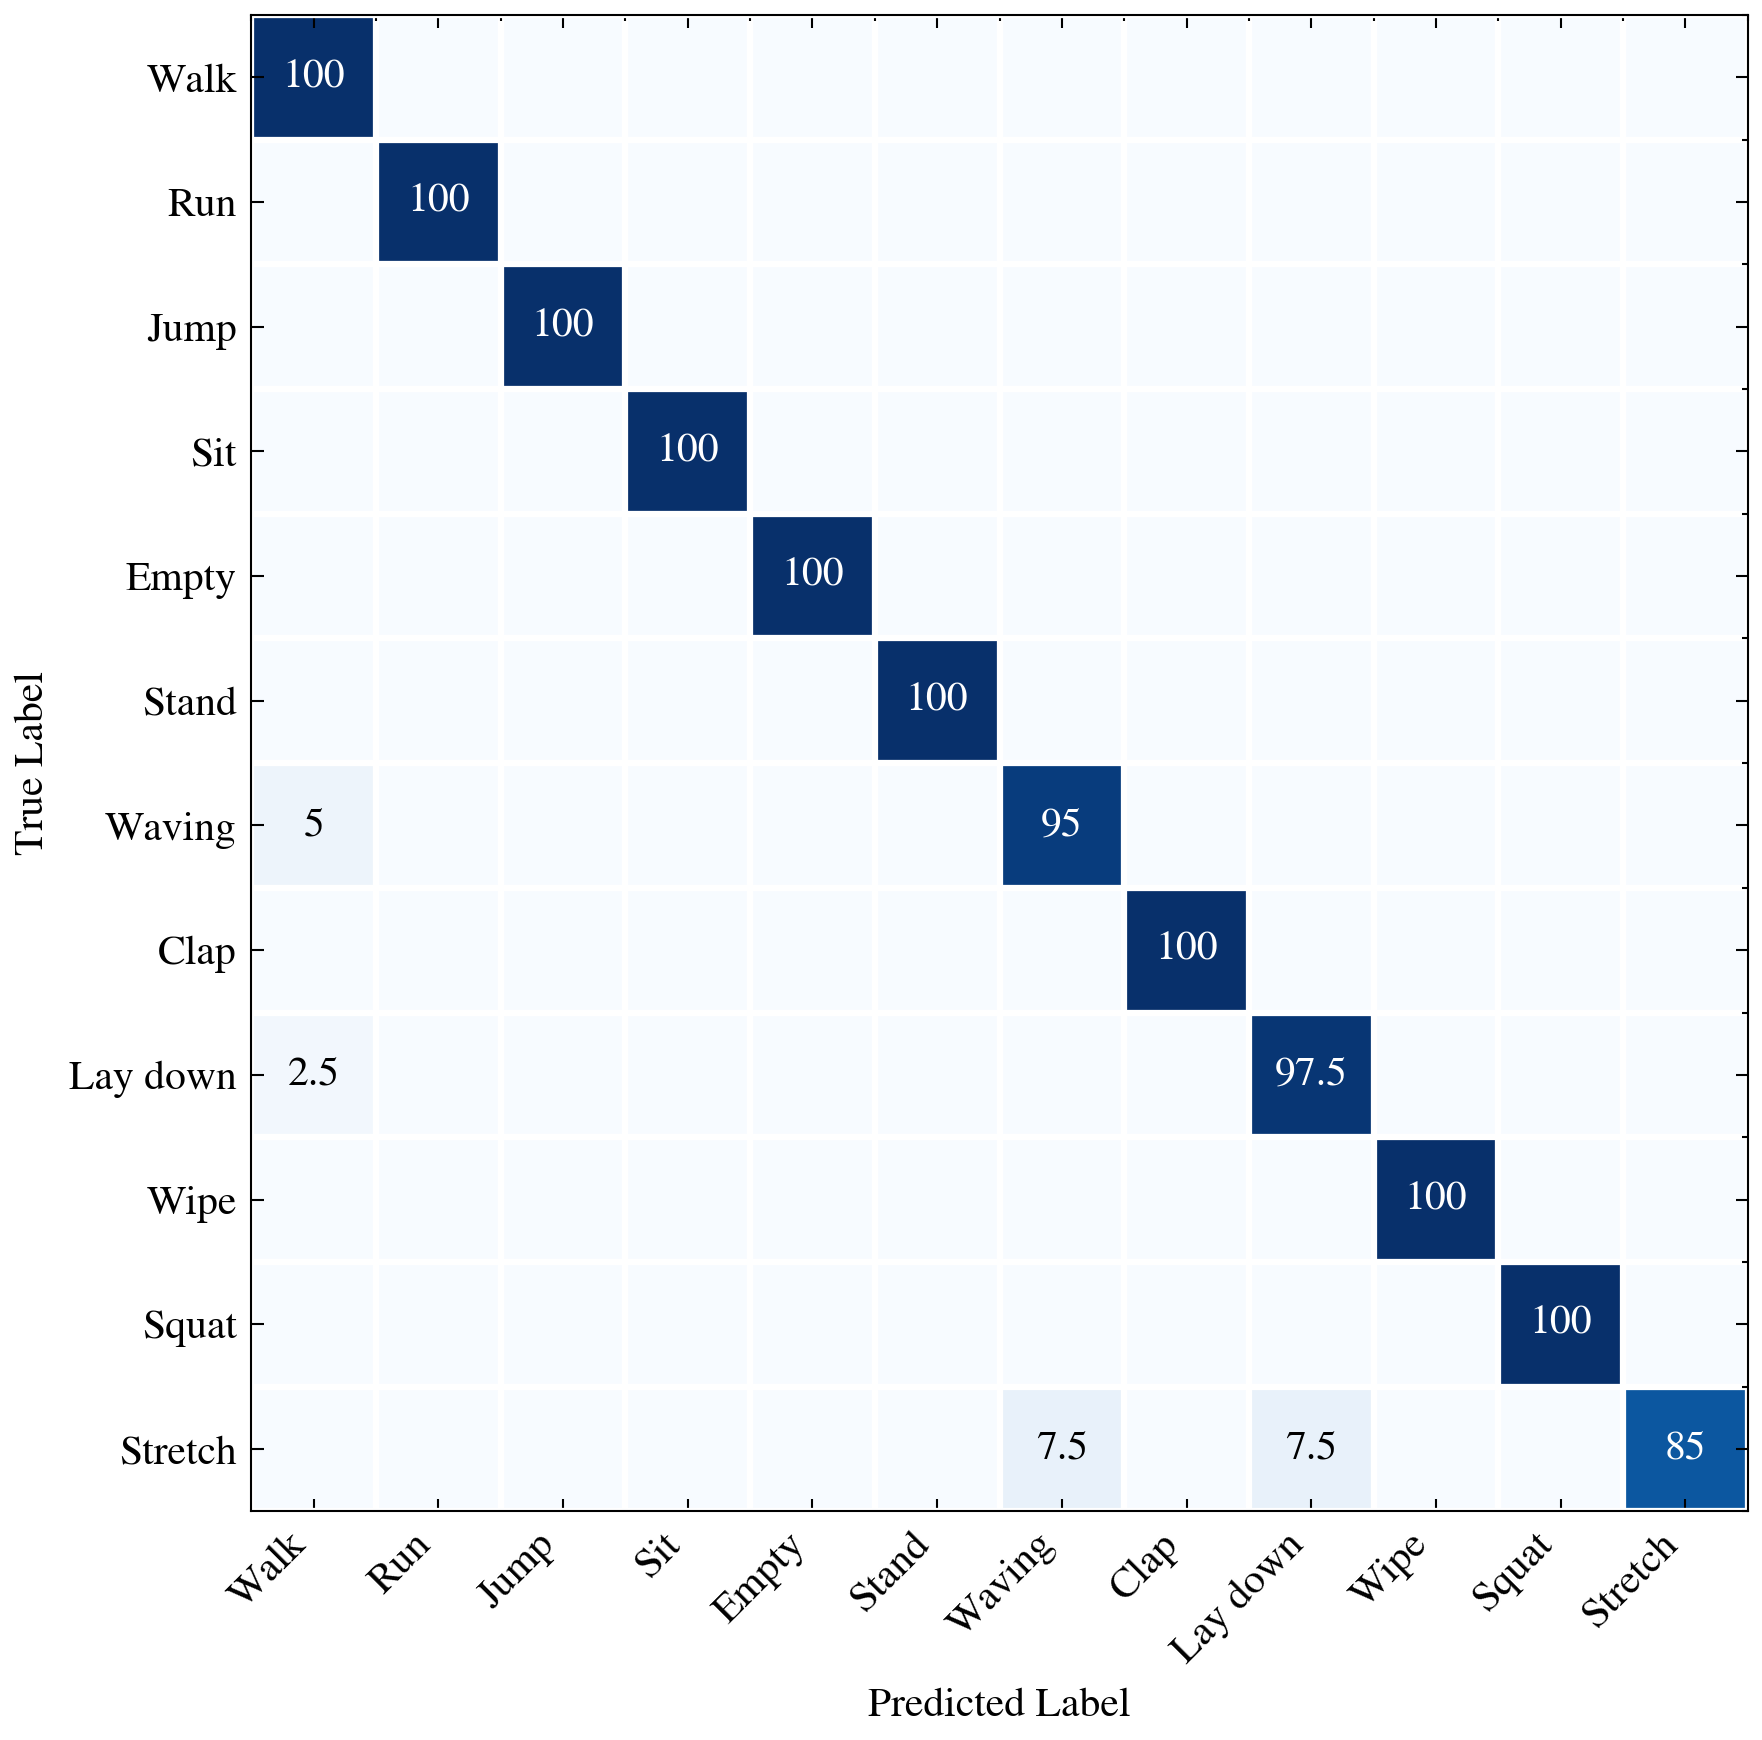

In [36]:
gaussians = [
    vae.SingleAntenna(
        settings.window_size,
        settings.n_subcarriers,
        best_model["n_gaussians"],
        vae.CONV_SPECS[best_model["params"]["conv_layers_spec"]],
    ).to(DEVICE)
    for _ in range(settings.n_antennas)
]
delayed_fusion = fusion.Delayed(
    gaussians,
    best_model["n_gaussians"],
    settings.n_activities,
    best_model["params"]["n_fusion_layers"],
    best_model["params"]["fusion_dropout"],
).to(DEVICE)

model_path = (
    WEIGHTS_DIR
    / f"l{best_model['n_gaussians']}"
    / f"t{best_model['trial_number']}"
    / f"s{best_model['seed']}"
    / "delayed_fusion.pt"
)
delayed_fusion.load_state_dict(torch.load(model_path))

full_dl = make_dataloader(full_ds, settings.batch_size, shuffle=False, seed=best_model["seed"])
test_dl = make_dataloader(full_test_ds, settings.batch_size, shuffle=False, seed=best_model["seed"])

plot_tsne(gaussians, full_dl, best_model["seed"])
plot_confusion_matrix(delayed_fusion, test_dl)